**MAGE**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

#installing dependencies if needed
!pip install -q transformers datasets torch tqdm scikit-learn

#imports
import os, pandas as pd, numpy as np, torch
from tqdm import tqdm
from sklearn.metrics import roc_auc_score, accuracy_score

Mounted at /content/drive


In [ ]:
#loading dataset from Drive and parse edit columns
dataset_path = "/content/drive/MyDrive/Beemo/dataset.parquet"
df = pd.read_parquet(dataset_path)
print("Loaded df shape:", df.shape)

import ast
def extract_first_edit(edit_str):
    #safely parse the JSON-like edit fields and extract first edit text
    try:
        edits = ast.literal_eval(edit_str)
        if isinstance(edits, list) and len(edits) > 0:
            return list(edits[0].values())[0]
    except Exception:
        pass
    return str(edit_str)

#creating parsed text columns used in tasks
df["human_output"] = df["human_output"].astype(str)
df["model_output"] = df["model_output"].astype(str)
df["human_edits_parsed"] = df["human_edits"].apply(lambda x: extract_first_edit(str(x)))
df["llama_edit_text"] = df["llama-3.1-70b_edits"].apply(lambda x: extract_first_edit(str(x)))
df["gpt4_edit_text"] = df["gpt-4o_edits"].apply(lambda x: extract_first_edit(str(x)))

print("Sample rows:")
display(df.head())

Loaded df shape: (2187, 10)
Sample rows:


,id,category,model,prompt_id,prompt,model_output,human_output,human_edits,llama-3.1-70b_edits,gpt-4o_edits,human_edits_parsed,llama_edit_text,gpt4_edit_text
0,0,Closed QA,HuggingFaceH4/zephyr-7b-beta,bc8dee50b2716928c9a16d96bd31db16d8a5f4dc830f67...,Who beat the Highland Society of Scotland in p...,Robert Armstrong beat the Highland Society of ...,Robert Armstrong released his dictionary in 18...,Robert Armstrong published a Scottish Gaelic d...,"[{'P1': ""Robert Archibald Armstrong beat the H...","[{'P1': ""Robert Armstrong beat the Highland So...",Robert Armstrong published a Scottish Gaelic d...,Robert Archibald Armstrong beat the Highland S...,Robert Armstrong beat the Highland Society of ...
1,1,Closed QA,meta-llama/Llama-2-13b-chat-hf,a88b3d44f1598abfb32011ef71e859618a69c60e54d77a...,What family is the swordfish a part of?\nWhat ...,"Sure, I can answer your questions based on the...",Swordfish are in the family Xiphiidae.\nThe lo...,The swordfish is the only member of the family...,"[{'P1': ""Here's the edited text:\n\nThe swordf...",[{'P1': 'What family is the swordfish a part o...,The swordfish is the only member of the family...,Here's the edited text:\n\nThe swordfish belon...,What family is the swordfish a part of?\nAnswe...
2,2,Closed QA,google/gemma-2b-it,9f0b2b5307a87aa2c3d600d28daf127f5f943b5aa06ff6...,"According to this statement from Chick-fil-A, ...","According to the statement, Chick-fil-A's core...",Chick-fil-A says they do their best work throu...,"According to this statement, Chick-fil-A does ...","[{'P1': ""According to the statement, Chick-fil...","[{'P1': 'According to the statement, Chick-fil...","According to this statement, Chick-fil-A does ...","According to the statement, Chick-fil-A's core...","According to the statement, Chick-fil-A believ..."
3,3,Closed QA,mistralai/Mixtral-8x7B-Instruct-v0.1,4bd24fc6b9bac35b23f761965515dce335554a0150a26e...,"After reading the text below, answer these que...",1. Trieste is located at the head of the Gulf ...,1. Trieste is located at the head of the Gulf ...,The city of Trieste is located at the head of ...,[{'P1': '1. Trieste is located at the head of ...,[{'P1': '1. Trieste is located at the head of ...,The city of Trieste is located at the head of ...,1. Trieste is located at the head of the Gulf ...,1. Trieste is located at the head of the Gulf ...
4,4,Closed QA,mistralai/Mixtral-8x7B-Instruct-v0.1,3d701bcf2811e91950d7766cdbd2660e2ee02be6825f8e...,Is the following statement true or false? Keep...,The statement is true. Keeping a plant healthy...,The statement is true.,The statement is true; keeping a plant healthy...,[{'P1': 'The statement is true. As the passage...,[{'P1': 'The statement is true. Keeping a plan...,The statement is true; keeping a plant healthy...,The statement is true. As the passage suggests...,The statement is true. Keeping a plant healthy...


In [ ]:
#loading MAGE model and tokenizer
from transformers import AutoTokenizer, AutoModelForSequenceClassification

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

model_name = "yaful/MAGE"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name).to(device)
model.eval()

print("Loaded", model_name)

Device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/382 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/595M [00:00<?, ?B/s]

Loaded yaful/MAGE


In [ ]:
#scoring function and evaluation for all 7 tasks
import torch.nn.functional as F


CHUNK_SIZE = 512     # matching MAGE's training window
MAX_LENGTH = 512
TEMP = 1.0           

tasks = {
 'H_vs_M': ('human_output', 'model_output'),
 'E_vs_M': ('human_edits_parsed', 'model_output'),
 'H_vs_E': ('human_output', 'human_edits_parsed'),
 'L_vs_M': ('llama_edit_text', 'model_output'),
 'H_vs_L': ('human_output', 'llama_edit_text'),
 'G_vs_M': ('gpt4_edit_text', 'model_output'),
 'H_vs_G': ('human_output', 'gpt4_edit_text'),
}


def get_scores_for_texts(texts, tokenizer, model, device,
                         chunk_size=CHUNK_SIZE, max_length=MAX_LENGTH, temp=TEMP):
    #Compute MAGE AI-probability scores (chunk-aware)
    scores = []
    for text in tqdm(texts, desc="Scoring texts", ncols=80):
        try:
            if chunk_size is None:
                #single-pass (truncate)
                inputs = tokenizer(
                    text,
                    truncation=True,
                    padding=True,
                    max_length=max_length,
                    return_tensors="pt"
                ).to(device)
                with torch.no_grad():
                    logits = model(**inputs).logits
                #using class 1 = machine probability
                prob = torch.softmax(logits / temp, dim=-1)[0, 1].item()
                scores.append(prob)
            else:
                #chunked scoring
                ids = tokenizer.encode(text, add_special_tokens=True, truncation=False)
                if len(ids) == 0:
                    scores.append(0.5)
                    continue
                chunk_probs = []
                for i in range(0, len(ids), chunk_size):
                    chunk_ids = ids[i:i+chunk_size]
                    input_ids = torch.tensor([chunk_ids]).to(device)
                    attention_mask = torch.ones_like(input_ids).to(device)
                    with torch.no_grad():
                        logits = model(input_ids=input_ids, attention_mask=attention_mask).logits
                    # class 1 = AI probability
                    prob = torch.softmax(logits / temp, dim=-1)[0, 1].item()
                    chunk_probs.append(prob)
                #taking the **max** probability (not mean)
                scores.append(float(np.max(chunk_probs)) if len(chunk_probs) > 0 else 0.5)
        except Exception:
            scores.append(0.5)
    return scores


def evaluate_detector(df, tokenizer, model, device, tasks, chunk_size=CHUNK_SIZE):
    results = {}
    for name, (c1, c2) in tasks.items():
        print("\n" + "="*60)
        print(name)
        print("="*60)
        subset = df[[c1, c2]].dropna()

        #building text pairs and labels
        X, y = [], []
        for _, r in subset.iterrows():
            X.append(str(r[c1])); y.append(0)  # human
            X.append(str(r[c2])); y.append(1)  # machine

        #computing MAGE scores
        scores = get_scores_for_texts(X, tokenizer, model, device, chunk_size=chunk_size)

        auroc_1 = roc_auc_score(y, scores)
        auroc_2 = roc_auc_score(y, [1 - s for s in scores])
        auroc = max(auroc_1, auroc_2)
        if auroc_2 > auroc_1:
            scores = [1 - s for s in scores]

        #metrics
        thr = np.median(scores)
        preds = [1 if s > thr else 0 for s in scores]
        acc = accuracy_score(y, preds)
        print(f"AUROC={auroc:.4f}  Acc={acc:.4f}")

        results[name] = {"auroc": auroc, "accuracy": acc}
    return results


#running all
mage_results = evaluate_detector(df, tokenizer, model, device, tasks, chunk_size=CHUNK_SIZE)
mage_summary = pd.DataFrame(mage_results).T
print("\n========== SUMMARY (MAGE) ==========")
print(mage_summary.round(4))

#saving to Drive
outdir = "/content/drive/MyDrive/BEEMO_Reproducibility/results"
os.makedirs(outdir, exist_ok=True)
mage_summary.to_csv(os.path.join(outdir, "mage_summary_corrected.csv"))
print("Saved to", outdir)


 H_vs_M


Scoring texts:   0%|                                   | 0/4374 [00:00<?, ?it/s]Initializing global attention on CLS token...
Input ids are automatically padded to be a multiple of `config.attention_window`: 512
Scoring texts: 100%|████████████████████████| 4374/4374 [06:03<00:00, 12.04it/s]


AUROC=0.7319  Acc=0.6694

 E_vs_M


Scoring texts: 100%|████████████████████████| 4374/4374 [05:33<00:00, 13.12it/s]


AUROC=0.6248  Acc=0.5930

 H_vs_E


...

AUROC=0.6648  Acc=0.6232

 G_vs_M


Scoring texts: 100%|████████████████████████| 4374/4374 [05:21<00:00, 13.59it/s]


AUROC=0.5929  Acc=0.5720

 H_vs_G


Scoring texts: 100%|████████████████████████| 4374/4374 [05:15<00:00, 13.88it/s]


AUROC=0.6590  Acc=0.6173

========== SUMMARY (MAGE) ==========
         auroc  accuracy
H_vs_M  0.7319    0.6694
E_vs_M  0.6248    0.5930
H_vs_E  0.6156    0.5821
L_vs_M  0.5831    0.5629
H_vs_L  0.6648    0.6232
G_vs_M  0.5929    0.5720
H_vs_G  0.6590    0.6173
Saved to /content/drive/MyDrive/BEEMO_Reproducibility/results


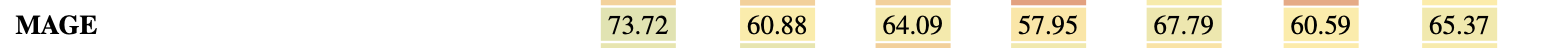